# Shallow Graph Embedding Demo

Questo notebook mostra tre metodi di shallow graph embedding:
- Local Linear Embedding (LLE)
- Laplacian Eigenmaps
- Graph Factorization (PyTorch)

e li visualizza su:
1. un toy graph altamente modulare;
2. il dataset CORA (PyTorch Geometric).

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_undirected

from shallow_graph_embedding import (
    LocalLinearEmbedding,
    LaplacianEigenmaps,
    GraphFactorization,
)

## 1) Highly modular test graph

In [5]:
rng = np.random.default_rng(42)

sizes = [35, 35, 35, 35]
probs = [
    [0.22, 0.008, 0.008, 0.008],
    [0.008, 0.22, 0.008, 0.008],
    [0.008, 0.008, 0.22, 0.008],
    [0.008, 0.008, 0.008, 0.22],
]

G_toy = nx.stochastic_block_model(sizes, probs, seed=42)
A_toy = nx.to_numpy_array(G_toy, dtype=float)

labels_toy = np.concatenate([np.full(s, i) for i, s in enumerate(sizes)])

# Features: one-hot encoding of the community + noise
one_hot = np.eye(len(sizes))[labels_toy]
noise = 0.08 * rng.normal(size=(A_toy.shape[0], 6))
X_toy = np.hstack([one_hot, noise])

print(f"Toy graph: {A_toy.shape[0]} nodes, {int(A_toy.sum() / 2)} edges")

Toy graph: 140 nodes, 551 edges


In [ ]:
def rbf_weight(x_i, x_j, sigma=1.0):
    diff = x_i - x_j
    return float(np.exp(-np.dot(diff, diff) / (2.0 * sigma**2)))

lle_toy = LocalLinearEmbedding(
    A_toy,
    n_components=2,
    reg=1e-3
).fit_transform(X_toy)
le_toy = LaplacianEigenmaps(
    A_toy,
    n_components=2,
    weight_function=None,
    #weight_function=lambda u, v: rbf_weight(u, v, sigma=1.0),
).fit_transform(X_toy)
gf_toy = GraphFactorization(
    A_toy,
    embedding_dim=2,
    epochs=2000,
    lr=0.03,
    reg=1e-4,
    negative_ratio=1.0,
    seed=42,
    verbose=False,
).fit_transform()

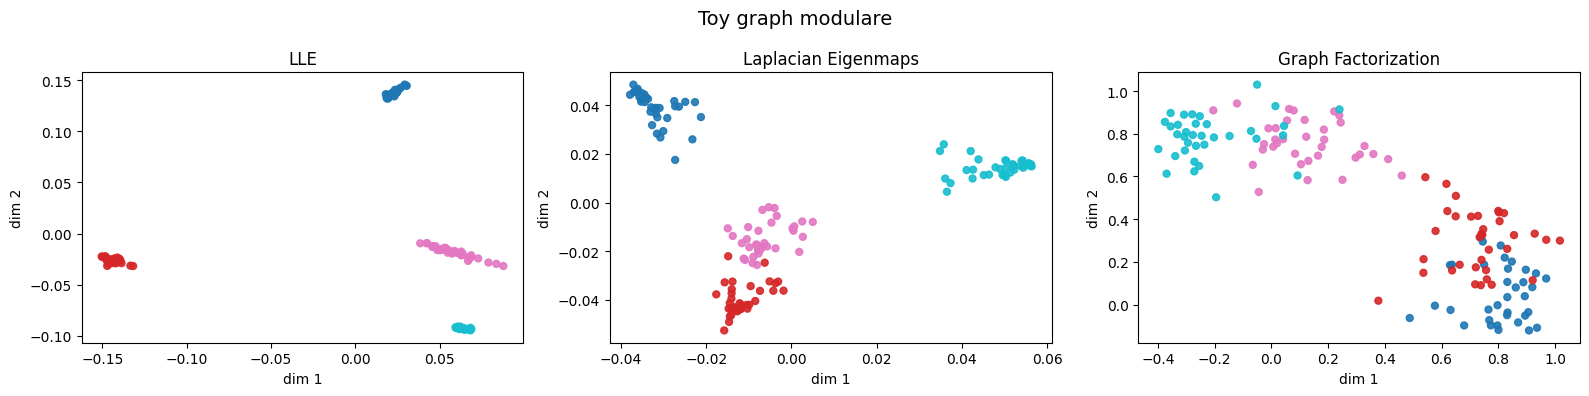

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
methods = [
    ("LLE", lle_toy),
    ("Laplacian Eigenmaps", le_toy),
    ("Graph Factorization", gf_toy),
]

for ax, (name, emb) in zip(axes, methods, strict=False):
    ax.scatter(emb[:, 0], emb[:, 1], c=labels_toy, cmap="tab10", s=25, alpha=0.9)
    ax.set_title(name)
    ax.set_xlabel("dim 1")
    ax.set_ylabel("dim 2")

fig.suptitle("Toy graph modulare", fontsize=14)
fig.tight_layout()
plt.show()

## 2) CORA (PyTorch Geometric)

In [8]:
dataset = Planetoid(root="./data/planetoid", name="Cora")
data = dataset[0]

num_nodes = data.num_nodes
edge_index = to_undirected(data.edge_index).cpu().numpy()

A_cora = np.zeros((num_nodes, num_nodes), dtype=float)
A_cora[edge_index[0], edge_index[1]] = 1.0
A_cora[edge_index[1], edge_index[0]] = 1.0

X_cora = data.x.cpu().numpy()
y_cora = data.y.cpu().numpy()

print(f"CORA: {num_nodes} nodi, {int(A_cora.sum() / 2)} archi, {X_cora.shape[1]} feature")

CORA: 2708 nodi, 5278 archi, 1433 feature


In [13]:
sigma = 2.0

lle_cora = LocalLinearEmbedding(
    A_cora, 
    n_components=2, 
    reg=1e-3
).fit_transform(X_cora)
le_cora = LaplacianEigenmaps(
    A_cora,
    n_components=2,
    weight_function=None,
).fit_transform(X_cora)
gf_cora = GraphFactorization(
    A_cora,
    embedding_dim=2,
    epochs=1000,
    lr=0.03,
    reg=1e-4,
    negative_ratio=0.5,
    seed=42,
    verbose=False,
).fit_transform()

/var/folders/0g/1jttpxw1401_195kbp64w5r40000gn/T/ipykernel_30426/1306772414.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


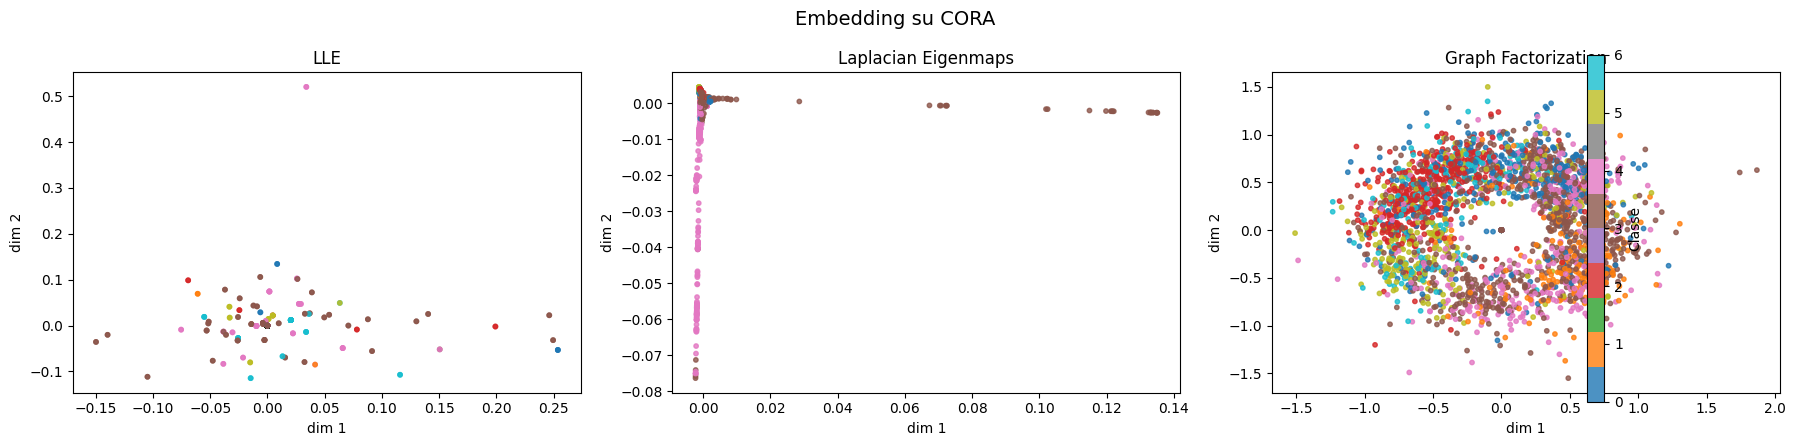

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
methods = [
    ("LLE", lle_cora),
    ("Laplacian Eigenmaps", le_cora),
    ("Graph Factorization", gf_cora),
]

for ax, (name, emb) in zip(axes, methods, strict=False):
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=y_cora, cmap="tab10", s=10, alpha=0.8)
    ax.set_title(name)
    ax.set_xlabel("dim 1")
    ax.set_ylabel("dim 2")

fig.suptitle("Embedding su CORA", fontsize=14)
fig.colorbar(sc, ax=axes.ravel().tolist(), fraction=0.02, pad=0.02, label="Classe")
fig.tight_layout()
plt.show()